<a href="https://colab.research.google.com/github/Mohsi777999/Machine-Learning-Labs/blob/main/Lab_02_Simple_And_Multiple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**By Mohsin Ali**

Import Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

Task 1

In [5]:
# Load the Diabetes dataset
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

print("Dataset shape:", X.shape)
print("Target shape:", y.shape)
print("Feature names:", diabetes.feature_names)

# Convert dataset into a DataFrame
df = pd.DataFrame(
    diabetes.data,
    columns=diabetes.feature_names
)
df["target"] = diabetes.target
display(df.head())

# Select BMI & Target
X_bmi = df[["bmi"]]
y = df["target"]

print("BMI shape:", X_bmi.shape)
print("Target shape:", y.shape)

Dataset shape: (442, 10)
Target shape: (442,)
Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


BMI shape: (442, 1)
Target shape: (442,)


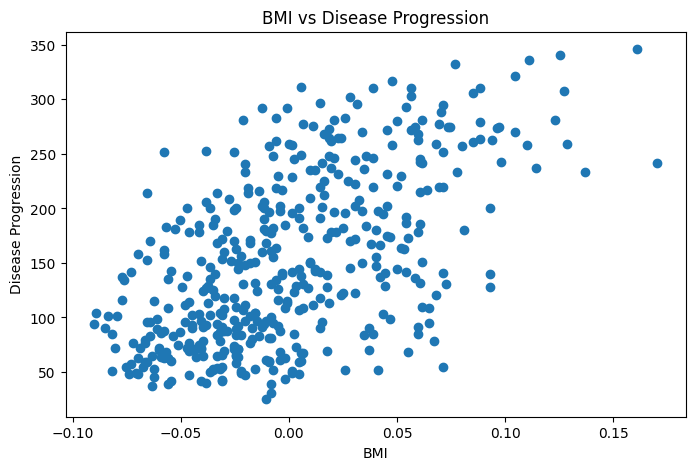

Correlation between BMI and Disease Progression: 0.5864501344746885


In [7]:
# Scatter plot: BMI vs Disease Progression
plt.figure(figsize=(8, 5))
plt.scatter(X_bmi, y)
plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.title("BMI vs Disease Progression")
plt.show()

# Calculate correlation between BMI and target
correlation = df["bmi"].corr(df["target"])
print("Correlation between BMI and Disease Progression:", correlation)

In [9]:
# Split BMI data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_bmi,
    y,
    test_size=0.20,
    random_state=42
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

# Create & Train Linear Regression model
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)
print("Intercept:", model_simple.intercept_)
print("BMI coefficient:", model_simple.coef_[0])

# Predict disease progression for test data
y_pred_simple = model_simple.predict(X_test)
print("First 10 predictions:")
print(y_pred_simple[:10])

Training data: (353, 1)
Testing data: (89, 1)
Intercept: 152.00335421448167
BMI coefficient: 998.5776891375598
First 10 predictions:
[145.80622687 188.85739048 147.95878505 203.92529774 131.8145987
 127.50948234 322.31599764 197.4676232   61.85645785 167.33180868]


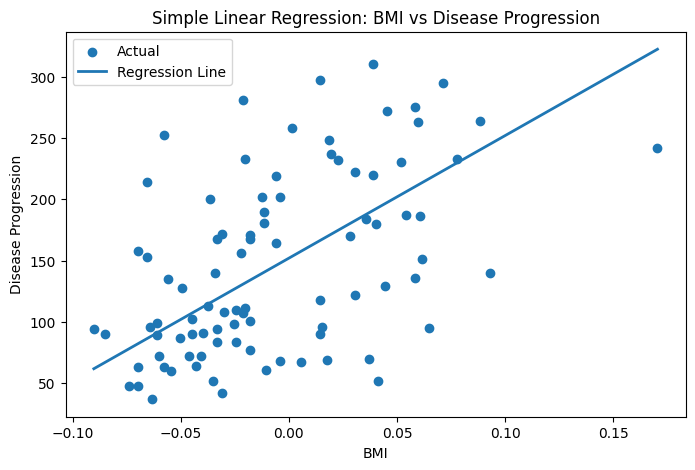

Simple Linear Regression MSE: 4061.8259284949268
Simple Linear Regression R²: 0.23335039815872138
BMI is useful, but it does not explain most of the variation by itself.


In [13]:
# Plot Regression Line
sort_index = X_test["bmi"].argsort()
X_test_sorted = X_test.iloc[sort_index]
y_pred_sorted = y_pred_simple[sort_index]

plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, label="Actual")
plt.plot(
    X_test_sorted,
    y_pred_sorted,
    linewidth=2,
    label="Regression Line"
)
plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.title("Simple Linear Regression: BMI vs Disease Progression")
plt.legend()
plt.show()

# Evaluate Simple Regression
mse_simple = mean_squared_error(y_test, y_pred_simple)
print("Simple Linear Regression MSE:", mse_simple)

r2_simple = r2_score(y_test, y_pred_simple)
print("Simple Linear Regression R²:", r2_simple)
print("BMI is useful, but it does not explain most of the variation by itself.")

Task 2

Features:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Feature shape: (442, 10)


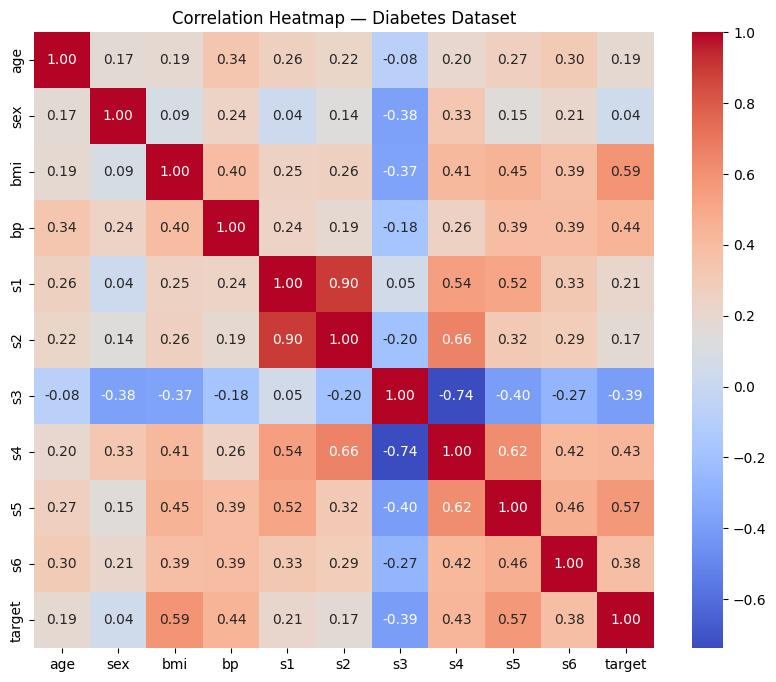

In [14]:
# Select all 10 independent variables
X_all = df[diabetes.feature_names]
y = df["target"]
print("Features:")
print(diabetes.feature_names)
print("\nFeature shape:", X_all.shape)

# Calculate correlation matrix
correlation_matrix = df[
    diabetes.feature_names + ["target"]
].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap — Diabetes Dataset")
plt.show()

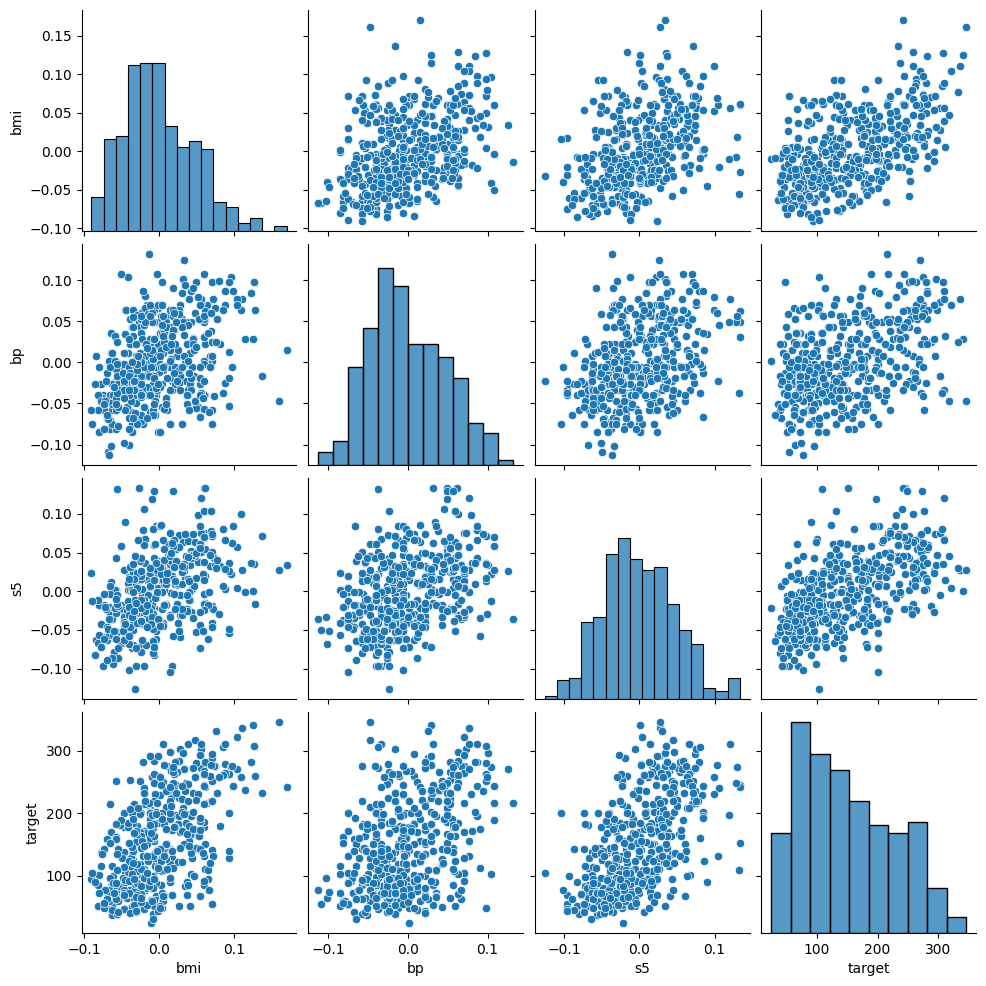

In [15]:
# Pair plot for selected features
selected_features = ["bmi", "bp", "s5", "target"]
sns.pairplot(df[selected_features])
plt.show()

Training data: (353, 10)
Testing data: (89, 10)
First 10 predictions:
[139.5475584  179.51720835 134.03875572 291.41702925 123.78965872
  92.1723465  258.23238899 181.33732057  90.22411311 108.63375858]


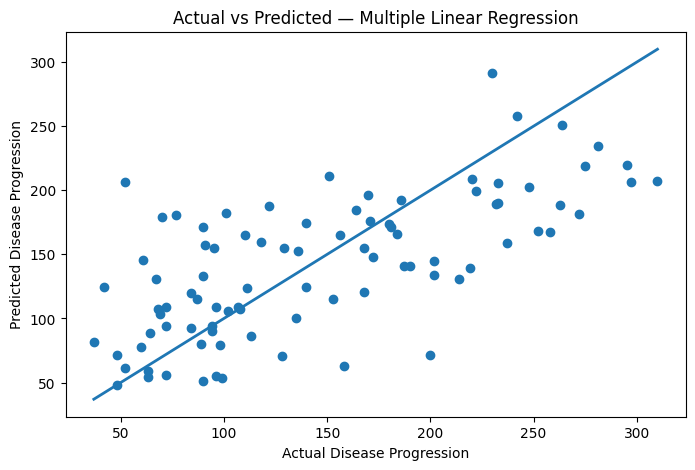

In [16]:
# Split Dataset
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_all,
    y,
    test_size=0.20,
    random_state=42
)
print("Training data:", X_train_multi.shape)
print("Testing data:", X_test_multi.shape)

# Create & Train Multiple Linear Regression model
model_multi = LinearRegression()
model_multi.fit(X_train_multi, y_train_multi)
y_pred_multi = model_multi.predict(X_test_multi)
print("First 10 predictions:")
print(y_pred_multi[:10])

# Actual vs Predicted values (Scatter Plot)
plt.figure(figsize=(8, 5))
plt.scatter(y_test_multi, y_pred_multi)
plt.plot(
    [y_test_multi.min(), y_test_multi.max()],
    [y_test_multi.min(), y_test_multi.max()],
    linewidth=2
)
plt.xlabel("Actual Disease Progression")
plt.ylabel("Predicted Disease Progression")
plt.title("Actual vs Predicted — Multiple Linear Regression")
plt.show()

First 10 residuals:
287     79.452442
211   -109.517208
72      67.961244
321    -61.417029
73     -12.789659
418     -8.172347
367    -16.232389
354     90.662679
281      3.775887
148    -12.633759
Name: target, dtype: float64


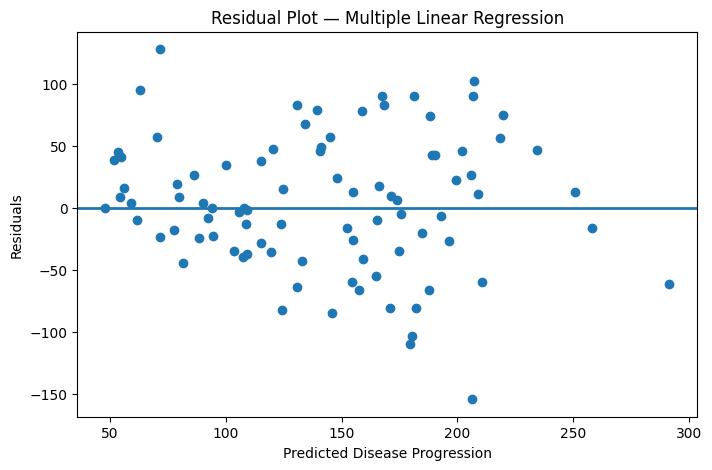

Multiple Linear Regression MSE: 2900.193628493482
Multiple Linear Regression RMSE: 53.85344583676593
Multiple Linear Regression R²: 0.4526027629719195


,Feature,Coefficient,Absolute Coefficient
4,s1,-931.488846,931.488846
8,s5,736.198859,736.198859
2,bmi,542.428759,542.428759
5,s2,518.062277,518.062277
3,bp,347.703844,347.703844
7,s4,275.317902,275.317902
1,sex,-241.964362,241.964362
6,s3,163.419983,163.419983
9,s6,48.670657,48.670657
0,age,37.904021,37.904021


In [17]:
# Calculate residuals
residuals = y_test_multi - y_pred_multi
print("First 10 residuals:")
print(residuals[:10])

# Residual plot
plt.figure(figsize=(8, 5))
plt.scatter(y_pred_multi, residuals)
plt.axhline(y=0, linewidth=2)
plt.xlabel("Predicted Disease Progression")
plt.ylabel("Residuals")
plt.title("Residual Plot — Multiple Linear Regression")
plt.show()

# Mean Squared Error
mse_multi = mean_squared_error(
    y_test_multi,
    y_pred_multi
)
print("Multiple Linear Regression MSE:", mse_multi)

# Root Mean Squared Error
rmse_multi = np.sqrt(mse_multi)
print("Multiple Linear Regression RMSE:", rmse_multi)

# R² Score
r2_multi = r2_score(
    y_test_multi,
    y_pred_multi
)
print("Multiple Linear Regression R²:", r2_multi)

# Display coefficients of all features
coefficients = pd.DataFrame({
    "Feature": diabetes.feature_names,
    "Coefficient": model_multi.coef_
})
coefficients["Absolute Coefficient"] = coefficients["Coefficient"].abs()
coefficients = coefficients.sort_values(
    by="Absolute Coefficient",
    ascending=False
)
display(coefficients)

Task 3

In [18]:
# Compare model performance
comparison = pd.DataFrame({
    "Model": [
        "Simple Linear Regression (BMI)",
        "Multiple Linear Regression (10 Features)"
    ],
    "MSE": [
        mse_simple,
        mse_multi
    ],
    "RMSE": [
        np.sqrt(mse_simple),
        rmse_multi
    ],
    "R²": [
        r2_simple,
        r2_multi
    ]
})
print("\nModel Comparison:")
display(comparison)


Model Comparison:


,Model,MSE,RMSE,R²
0,Simple Linear Regression (BMI),4061.825928,63.732456,0.233350
1,Multiple Linear Regression (10 Features),2900.193628,53.853446,0.452603
